In [1]:
from pathlib import Path
import os
import sys

if Path.cwd().name == "notebooks":
    os.chdir("..")

ROOT = Path.cwd()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Working directory:", ROOT)

Working directory: e:\研究生\bootcamp\bootcamp_aixuan_liu\project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from src.modeling import (
    FEATURES,
    time_split,
    make_model
)

from src.evaluation import (
    r2_oos,
    bootstrap_rmse
)

In [3]:
data = pd.read_csv(
    "data/processed/factor_data.csv"
)

print(data.shape)

data.head()

(273, 25)


,Amount,MTTR,M_r,M_rf,PE,EPS,ROE,IPS,yyyymm,Beta,...,PEL1,EPSL1,ROEL1,IPSL1,MTTRL1,BetaL1,M_volL1,M_liqL1,M_highL1,M_skewL1
0,1.834463e+08,10.4055,0.0972,0.00165,63.28,0.25,6.2595,1.79,200103,0.9439,...,57.67,0.15,4.2458,0.95,4.5339,0.9459,0.004541,-0.004844,0.909467,-1.214501
1,1.927190e+08,10.5702,-0.0201,0.00165,77.93,0.25,6.2595,1.79,200104,0.9306,...,63.28,0.25,6.2595,1.79,10.4055,0.9439,0.005040,0.005108,0.942012,0.649947
2,3.678608e+08,18.6922,0.1776,0.00165,91.76,0.25,6.2595,1.79,200105,0.9608,...,77.93,0.25,6.2595,1.79,10.5702,0.9306,0.004062,-0.001054,0.960947,-0.466222
3,2.549595e+08,12.5965,-0.0680,0.00165,85.32,0.25,6.2595,1.79,200106,1.5167,...,91.76,0.25,6.2595,1.79,18.6922,0.9608,0.005383,0.009005,1.131158,1.794370
4,1.019137e+08,5.4369,-0.1452,0.00165,98.13,0.25,6.2595,1.79,200107,1.4484,...,85.32,0.25,6.2595,1.79,12.5965,1.5167,0.008531,-0.003513,0.997823,-0.476625


In [4]:
print(FEATURES)

['PEL1', 'EPSL1', 'ROEL1', 'IPSL1', 'MTTRL1', 'BetaL1', 'M_volL1', 'M_liqL1', 'M_highL1', 'M_skewL1']


In [5]:
train, test = time_split(
    data,
    0.7
)

print(
    "Train:",
    train["yyyymm"].min(),
    "to",
    train["yyyymm"].max()
)

print(
    "Test:",
    test["yyyymm"].min(),
    "to",
    test["yyyymm"].max()
)

print(
    "Train size:",
    len(train)
)

print(
    "Test size:",
    len(test)
)

Train: 200103 to 201702
Test: 201703 to 202312
Train size: 191
Test size: 82


## Scenario 1 — Baseline

The baseline model uses all ten lagged predictors:

PE, EPS, ROE, IPS, MTTR, Beta, M_vol, M_liq, M_high, and M_skew.

This represents the full multi-factor specification.

In [6]:
baseline_features = FEATURES

X_train_base = train[
    baseline_features
]

X_test_base = test[
    baseline_features
]

y_train = train[
    "M_ExRet"
]

y_test = test[
    "M_ExRet"
]

In [7]:
baseline_model = make_model(
    "ridge"
)

baseline_model.fit(
    X_train_base,
    y_train
)

pred_base = baseline_model.predict(
    X_test_base
)

In [8]:
baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_base
    )
)

baseline_mae = mean_absolute_error(
    y_test,
    pred_base
)

benchmark = np.repeat(
    y_train.mean(),
    len(y_test)
)

baseline_r2oos = r2_oos(
    y_test.to_numpy(),
    pred_base,
    benchmark
)

print(
    f"Baseline RMSE: {baseline_rmse:.6f}"
)

print(
    f"Baseline MAE: {baseline_mae:.6f}"
)

print(
    f"Baseline OOS R2: {baseline_r2oos:.4f}"
)

Baseline RMSE: 0.140871
Baseline MAE: 0.098963
Baseline OOS R2: -0.0077


## Scenario 2 — Selected Significant Factors

This scenario keeps only the three predictors that showed the strongest statistical evidence in the earlier experiment:

- M_liq
- M_high
- M_skew

The purpose is to test whether a smaller and more interpretable factor set improves out-of-sample stability relative to the full ten-factor specification.

In [10]:
selected_features = [
    "M_liqL1",
    "M_highL1",
    "M_skewL1"
]
X_train_selected = train[
    selected_features
]

X_test_selected = test[
    selected_features
]

selected_model = make_model(
    "ridge"
)

selected_model.fit(
    X_train_selected,
    y_train
)

pred_selected = selected_model.predict(
    X_test_selected
)

In [11]:
selected_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_selected
    )
)

selected_mae = mean_absolute_error(
    y_test,
    pred_selected
)

selected_r2oos = r2_oos(
    y_test.to_numpy(),
    pred_selected,
    benchmark
)

print(
    f"Selected RMSE: {selected_rmse:.6f}"
)

print(
    f"Selected MAE: {selected_mae:.6f}"
)

print(
    f"Selected OOS R2: {selected_r2oos:.4f}"
)

Selected RMSE: 0.140342
Selected MAE: 0.098551
Selected OOS R2: -0.0002


## Scenario 3 — Winsorized Data

In [12]:
def winsorize_series(
    s,
    lower=0.01,
    upper=0.99
):

    low = s.quantile(
        lower
    )

    high = s.quantile(
        upper
    )

    return s.clip(
        lower=low,
        upper=high
    )

In [13]:
train_w = train.copy()
test_w = test.copy()

winsor_limits = {}

for col in FEATURES:

    low = train[col].quantile(
        0.01
    )

    high = train[col].quantile(
        0.99
    )

    winsor_limits[col] = (
        low,
        high
    )

    train_w[col] = train[col].clip(
        lower=low,
        upper=high
    )

    test_w[col] = test[col].clip(
        lower=low,
        upper=high
    )

In [14]:
X_train_w = train_w[
    FEATURES
]

X_test_w = test_w[
    FEATURES
]

winsor_model = make_model(
    "ridge"
)

winsor_model.fit(
    X_train_w,
    y_train
)

pred_winsor = winsor_model.predict(
    X_test_w
)

In [15]:
winsor_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_winsor
    )
)

winsor_mae = mean_absolute_error(
    y_test,
    pred_winsor
)

winsor_r2oos = r2_oos(
    y_test.to_numpy(),
    pred_winsor,
    benchmark
)

print(
    f"Winsorized RMSE: {winsor_rmse:.6f}"
)

print(
    f"Winsorized MAE: {winsor_mae:.6f}"
)

print(
    f"Winsorized OOS R2: {winsor_r2oos:.4f}"
)

Winsorized RMSE: 0.142077
Winsorized MAE: 0.100216
Winsorized OOS R2: -0.0251


In [16]:
scenario_results = pd.DataFrame({
    "Scenario": [
        "Baseline - 10 factors",
        "Selected - 3 factors",
        "Winsorized - 10 factors"
    ],
    "RMSE": [
        baseline_rmse,
        selected_rmse,
        winsor_rmse
    ],
    "MAE": [
        baseline_mae,
        selected_mae,
        winsor_mae
    ],
    "OOS_R2": [
        baseline_r2oos,
        selected_r2oos,
        winsor_r2oos
    ]
})

scenario_results

,Scenario,RMSE,MAE,OOS_R2
0,Baseline - 10 factors,0.140871,0.098963,-0.007739
1,Selected - 3 factors,0.140342,0.098551,-0.000184
2,Winsorized - 10 factors,0.142077,0.100216,-0.025067


In [17]:
scenario_results.to_csv(
    "data/processed/scenario_results.csv",
    index=False
)

print(
    "Saved:",
    "data/processed/scenario_results.csv"
)

Saved: data/processed/scenario_results.csv


In [18]:
scenario_results[
    "RMSE_change_vs_baseline"
] = (
    scenario_results["RMSE"]
    - baseline_rmse
)

scenario_results[
    "MAE_change_vs_baseline"
] = (
    scenario_results["MAE"]
    - baseline_mae
)

scenario_results[
    "OOS_R2_change_vs_baseline"
] = (
    scenario_results["OOS_R2"]
    - baseline_r2oos
)

scenario_results

,Scenario,RMSE,MAE,OOS_R2,RMSE_change_vs_baseline,MAE_change_vs_baseline,OOS_R2_change_vs_baseline
0,Baseline - 10 factors,0.140871,0.098963,-0.007739,0.000000,0.000000,0.000000
1,Selected - 3 factors,0.140342,0.098551,-0.000184,-0.000529,-0.000411,0.007555
2,Winsorized - 10 factors,0.142077,0.100216,-0.025067,0.001206,0.001254,-0.017328


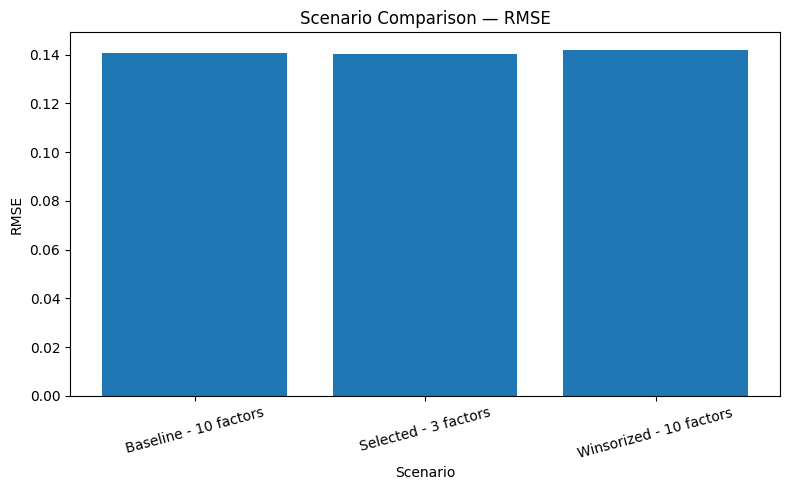

In [19]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    scenario_results[
        "Scenario"
    ],
    scenario_results[
        "RMSE"
    ]
)

plt.ylabel(
    "RMSE"
)

plt.xlabel(
    "Scenario"
)

plt.title(
    "Scenario Comparison — RMSE"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()

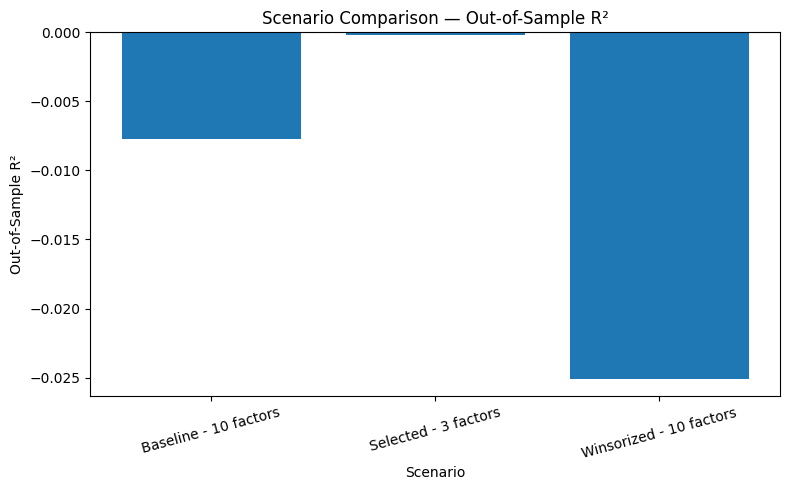

In [20]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    scenario_results[
        "Scenario"
    ],
    scenario_results[
        "OOS_R2"
    ]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.ylabel(
    "Out-of-Sample R²"
)

plt.xlabel(
    "Scenario"
)

plt.title(
    "Scenario Comparison — Out-of-Sample R²"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()

## Bootstrap uncertainty

In [21]:
boot_base = bootstrap_rmse(
    y_test.to_numpy(),
    pred_base,
    n_boot=1000,
    seed=42
)

boot_selected = bootstrap_rmse(
    y_test.to_numpy(),
    pred_selected,
    n_boot=1000,
    seed=42
)

boot_winsor = bootstrap_rmse(
    y_test.to_numpy(),
    pred_winsor,
    n_boot=1000,
    seed=42
)

boot_base

{'mean': np.float64(0.13922806876213875),
 'lower': np.float64(0.10553996955956862),
 'upper': np.float64(0.1775266441640834)}

In [22]:
bootstrap_table = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "Selected",
        "Winsorized"
    ],
    "RMSE_mean": [
        boot_base["mean"],
        boot_selected["mean"],
        boot_winsor["mean"]
    ],
    "CI_lower": [
        boot_base["lower"],
        boot_selected["lower"],
        boot_winsor["lower"]
    ],
    "CI_upper": [
        boot_base["upper"],
        boot_selected["upper"],
        boot_winsor["upper"]
    ]
})

bootstrap_table

,Scenario,RMSE_mean,CI_lower,CI_upper
0,Baseline,0.139228,0.105540,0.177527
1,Selected,0.138684,0.104974,0.177372
2,Winsorized,0.140476,0.107214,0.178731


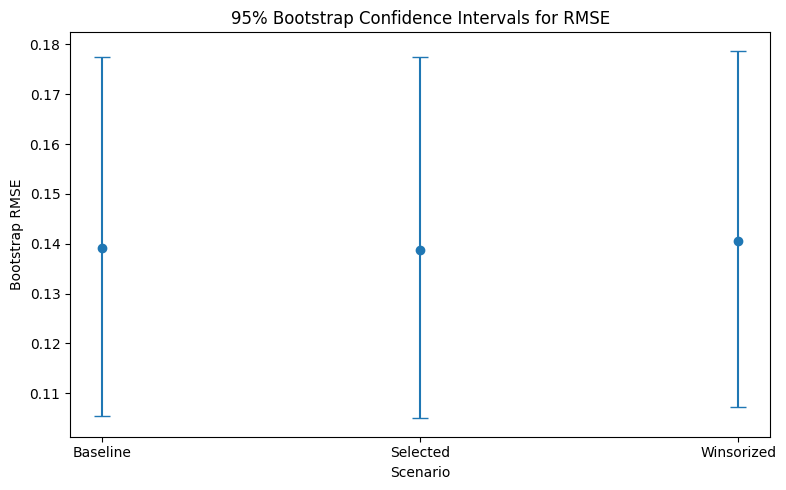

In [23]:
means = (
    bootstrap_table[
        "RMSE_mean"
    ].to_numpy()
)

lower_err = (
    means
    - bootstrap_table[
        "CI_lower"
    ].to_numpy()
)

upper_err = (
    bootstrap_table[
        "CI_upper"
    ].to_numpy()
    - means
)

plt.figure(
    figsize=(8, 5)
)

plt.errorbar(
    bootstrap_table[
        "Scenario"
    ],
    means,
    yerr=[
        lower_err,
        upper_err
    ],
    fmt="o",
    capsize=6
)

plt.ylabel(
    "Bootstrap RMSE"
)

plt.xlabel(
    "Scenario"
)

plt.title(
    "95% Bootstrap Confidence Intervals for RMSE"
)

plt.tight_layout()

plt.show()

## Scenario Analysis Interpretation

Three scenarios were compared using the same time-aware train/test split.

### Baseline

The baseline specification uses all ten lagged predictors and serves as the reference model.

### Selected-Factor Scenario

The selected-factor specification uses only `M_liq`, `M_high`, and `M_skew`, which showed the strongest statistical evidence in the earlier experiment.

If this scenario produces lower RMSE / MAE or higher out-of-sample R² than the baseline, it suggests that removing weak predictors may improve model stability and reduce overfitting.

If performance deteriorates, the remaining factors may still contain useful joint information even if they are individually insignificant.

### Winsorized Scenario

The winsorized scenario limits extreme predictor values using thresholds estimated only from the training sample.

If performance improves, this suggests that the baseline model is sensitive to extreme observations.

If results remain similar, the model appears relatively robust to outlier treatment.

### Overall Risk Interpretation

Model conclusions should not rely on a single specification. If all three scenarios produce similar out-of-sample metrics and overlapping bootstrap confidence intervals, the findings are relatively robust.

Large changes across scenarios would indicate that model performance depends strongly on factor selection or outlier assumptions.

In [25]:
from pathlib import Path

Path(
    "reports/images"
).mkdir(
    parents=True,
    exist_ok=True
)

In [26]:
plt.savefig(
    "reports/images/scenario_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [27]:
plt.savefig(
    "reports/images/scenario_bootstrap_ci.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>